## 3번 세그대중성 & 팬덤 상위권: 앵커 / 얼굴마담 / 간판 / 슈퍼노바 (Supernova, 초신성)
가장 밝게 빛나며 시스템 전체에 영향력을 미치는 중심적 존재입니다.

3번 세그먼트는 개인, 그룹, 기업/크루 여부와 관계없이  
플랫폼 내 대중성, 방송 화력, 팬덤 결집력과 외부 확장성을 함께 가진 스트리머를 찾기 위한 세그먼트이다.

기업/크루/그룹/개인 여부는 완전한 공식 데이터가 아니므로,  
전체 순위를 먼저 확인한 뒤 팬카페 기준 구분과 수동 기업 리스트를 활용해 보조적으로 나누어 비교했다.

### 라이브러리

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm
import math
from sklearn.preprocessing import MinMaxScaler

In [132]:
df = pd.read_csv("../data/final_softcone.csv")

# 윈도우 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
df

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,팬카페_그룹여부
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,False
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,True
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,True
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,True
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11152,sophiaten,SOOP,sophiaten,2026.03.20 ~ 2026.03.20,5,1,0,0,2,0,0,0,361.5,-100.0,0,3900,0,NaN
11153,한유0612,CHZZK,e982cd3a6093de657fa34db1bc42e98a,2026.03.30 ~ 2026.03.30,22,0,0,0,0,0,0,0,-100.0,-100.0,0,0,0,NaN
11154,dj12jdhs,SOOP,dj12jdhs,2026.03.08 ~ 2026.03.08,0,0,4,2,3,3,0,0,0.0,0.0,0,0,0,NaN
11155,afueo039,SOOP,afueo039,2025.01.21 ~ 2026.03.10,2,18,2,2,2,2,0,0,-100.0,-100.0,0,0,0,NaN


In [133]:
df.head()

,스트리머명,플랫폼,채널ID,집계기간_내_최초_방송일,최고_팔로워,총_방송시간,6분_최고채팅,6분_평균채팅_최댓값,최고_시청자,평균_시청자_최댓값,뷰어십,도네이션,유튜브_유입지수,팬덤지수,X_팔로워,유튜브_구독자,팬카페_가입자,팬카페_그룹여부
0,탬탬버린,CHZZK,a7e175625fdea5a7d98428302b7aa57f,2025.01.01 ~ 2026.03.31,308659,2769,5923,2346,23115,13532,17075004,6876167,4.4,-13.9,0,537000,46191,False
1,텐코 시부키,CHZZK,64d76089fba26b180d9c9e48a32600d9,2025.01.01 ~ 2026.03.31,222276,2368,7255,4660,34645,16465,14216251,6737178,-0.7,4.1,78000,204000,252724,True
2,아리사,CHZZK,4de764d9dad3b25602284be6db3ac647,2025.01.01 ~ 2026.03.31,84836,4218,7123,3100,12994,8066,11904276,6932861,-0.8,-6.2,7028,77600,30431,True
3,아라하시 타비,CHZZK,a6c4ddb09cdb160478996007bff35296,2025.01.01 ~ 2026.03.31,232937,2409,6976,4840,28568,12483,11350960,6733563,-0.1,4.0,89000,230000,252724,True
4,고세구,SOOP,gosegu2,2025.01.01 ~ 2026.03.31,199696,1558,95063,17283,39102,23877,10855404,5905590,8.2,9.8,0,545000,573411,True


In [134]:
df.columns

Index(['스트리머명', '플랫폼', '채널ID', '집계기간_내_최초_방송일', '최고_팔로워', '총_방송시간', '6분_최고채팅',
       '6분_평균채팅_최댓값', '최고_시청자', '평균_시청자_최댓값', '뷰어십', '도네이션', '유튜브_유입지수',
       '팬덤지수', 'X_팔로워', '유튜브_구독자', '팬카페_가입자', '팬카페_그룹여부'],
      dtype='str')

---
### 소속구분 기준

`팬카페_그룹여부` 컬럼은 다음과 같이 해석했다.

| 값 | 해석 |
|---|---|
| True | 그룹 팬카페로 판단된 대상 |
| False | 개인 팬카페로 판단된 대상 |
| NaN | 팬카페 정보 없음 또는 확인 불가 |

기업/크루 여부는 별도 공식 컬럼이 없기 때문에 수동 리스트 기준으로 참고용 분류만 진행했다.  
따라서 본 분석에서는 전체 순위를 가장 우선으로 보고, 소속구분별 결과는 보조적으로 확인한다.

---
### 기업소속 확인

In [135]:
# 기업/소속/아이돌/크루로 볼 대상 리스트
# 팀 기준에 맞게 계속 추가/수정하면 됨
company_or_group_names = [
    # 예시
    "아이네", "징버거", "릴파", "주르르", "고세구", "비챤",
    "우왁굳",
    "아야츠노 유니", "사키하네 후야", "시라유키 히나", "네네코 마시로", "아카네 리제", "아라하시 타비","텐코 시부키", "아오쿠모 린", "하나코 나나", "유즈하 리코",
    "탬탬버린", "제갈금자", "강지", "유소나"
]

In [136]:
seg3_df = df.copy()

# 팬카페_그룹여부 정리
def parse_group_value(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().upper()
    
    if x == "TRUE":
        return True
    elif x == "FALSE":
        return False
    else:
        return np.nan

seg3_df["팬카페_그룹여부_정리"] = seg3_df["팬카페_그룹여부"].apply(parse_group_value)

# 기본값: 팬카페없음
seg3_df["소속구분"] = "팬카페없음"

seg3_df.loc[
    seg3_df["팬카페_그룹여부_정리"] == False,
    "소속구분"
] = "개인팬카페"

seg3_df.loc[
    seg3_df["팬카페_그룹여부_정리"] == True,
    "소속구분"
] = "그룹/크루팬카페"

# 기업/크루 리스트는 참고용
seg3_df.loc[
    seg3_df["스트리머명"].isin(company_or_group_names),
    "소속구분"
] = "기업"

seg3_df["소속구분"].value_counts(dropna=False)

소속구분
팬카페없음       7204
개인팬카페       3472
그룹/크루팬카페     461
기업            20
Name: count, dtype: int64

---
### 세그먼트 점수 산정 방식

3번 세그먼트 점수는 “간판형 스트리머”를 찾기 위해  
다음 세 가지 축으로 구성했다.

1. **대중성**
   - 최고 팔로워
   - 최고 시청자
   - 유튜브 유입지수

2. **방송 화력**
   - 도네이션
   - 6분 최고채팅
   - 평균 시청자 최댓값

3. **팬덤 결집 및 누적 규모**
   - 팬덤지수
   - 뷰어십

값의 범위가 큰 지표는 `log1p` 변환을 적용해 극단값의 영향을 완화했고,  
이후 모든 지표를 0~100점으로 정규화한 뒤 가중합하여 최종 점수를 계산했다.

### 최종 계산식

3번 세그먼트 점수는 다음과 같이 계산했다.

대중성 점수 = 최고팔로워 50% + 최고시청자 30% + 유튜브유입지수 20%

방송화력 점수 = 도네이션 40% + 채팅화력 30% + 평균시청자 30%

팬덤확장 점수 = 팬덤지수 60% + 뷰어십 40%

최종 세그먼트 점수 = 대중성 35% + 방송화력 40% + 팬덤확장 25%

이 방식은 특정 소속 유형에 한정하지 않고,  
방송 내 체급과 반응성, 외부 인지도, 팬덤 결집력을 함께 가진 핵심 스트리머를 찾기 위한 기준이다.

In [137]:
score_cols = [
    "최고_팔로워",
    "최고_시청자",
    "유튜브_유입지수",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "팬덤지수",
    "뷰어십"
]

for col in score_cols:
    seg3_df[col] = pd.to_numeric(seg3_df[col], errors="coerce").fillna(0)

# 값 차이가 큰 지표는 로그 변환
log_cols = [
    "최고_팔로워",
    "최고_시청자",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "뷰어십"
]

for col in log_cols:
    seg3_df[f"log_{col}"] = np.log1p(seg3_df[col])

# 유튜브_유입지수, 팬덤지수는 음수 가능성이 있으므로 로그 변환하지 않음
scale_input_cols = [
    "log_최고_팔로워",
    "log_최고_시청자",
    "유튜브_유입지수",
    "log_도네이션",
    "log_6분_최고채팅",
    "log_평균_시청자_최댓값",
    "팬덤지수",
    "log_뷰어십"
]

scaled_cols = [
    "팔로워_score",
    "최고시청자_score",
    "유튜브유입_score",
    "도네이션_score",
    "채팅화력_score",
    "평균시청자_score",
    "팬덤_score",
    "뷰어십_score"
]

scaler = MinMaxScaler()
seg3_df[scaled_cols] = scaler.fit_transform(seg3_df[scale_input_cols]) * 100

In [138]:
# 1. 대중성 점수
seg3_df["대중성_score"] = (
    seg3_df["팔로워_score"] * 0.50 +
    seg3_df["최고시청자_score"] * 0.30 +
    seg3_df["유튜브유입_score"] * 0.20
)

# 2. 방송화력 점수
seg3_df["방송화력_score"] = (
    seg3_df["도네이션_score"] * 0.40 +
    seg3_df["채팅화력_score"] * 0.30 +
    seg3_df["평균시청자_score"] * 0.30
)

# 3. 팬덤확장 점수
seg3_df["팬덤확장_score"] = (
    seg3_df["팬덤_score"] * 0.60 +
    seg3_df["뷰어십_score"] * 0.40
)

# 4. 최종 세그먼트3 점수
seg3_df["세그먼트3_score"] = (
    seg3_df["대중성_score"] * 0.35 +
    seg3_df["방송화력_score"] * 0.40 +
    seg3_df["팬덤확장_score"] * 0.25
)

In [139]:
result_cols = [
    "스트리머명",
    "플랫폼",
    "소속구분",
    "팬카페_그룹여부",
    "최고_팔로워",
    "최고_시청자",
    "도네이션",
    "6분_최고채팅",
    "평균_시청자_최댓값",
    "유튜브_유입지수",
    "팬덤지수",
    "뷰어십",
    "대중성_score",
    "방송화력_score",
    "팬덤확장_score",
    "세그먼트3_score"
]

seg3_result = (
    seg3_df[result_cols]
    .sort_values("세그먼트3_score", ascending=False)
    .reset_index(drop=True)
)

seg3_result.head(30)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤확장_score,세그먼트3_score
0,고세구,SOOP,기업,True,199696,39102,5905590,95063,23877,8.2,9.8,10855404,79.019462,98.459542,51.173336,79.833963
1,비챤,SOOP,기업,True,176315,20891,2862540,108416,16694,5.2,10.9,5657369,76.725293,95.924277,49.730812,77.656266
2,시라유키 히나,CHZZK,기업,True,219675,47218,6864206,6960,30958,2.6,4.4,8608945,79.791528,92.830024,50.013402,77.562395
3,주르르,SOOP,기업,True,175519,27415,3250999,55406,17295,7.2,11.0,4794346,77.508985,94.612701,49.344404,77.309326
4,텐코 시부키,CHZZK,기업,True,222276,34645,6737178,7255,16465,-0.7,4.1,14216251,78.901949,91.058295,51.184681,76.835171
5,릴파,SOOP,기업,True,185167,21790,5796867,13983,18865,7.0,10.5,7788723,77.071409,92.769388,50.454091,76.696271
6,아카네 리제,CHZZK,기업,True,235506,40960,6069644,5873,23109,2.5,3.9,5983879,79.662059,91.230281,49.083899,76.644808
7,유즈하 리코,CHZZK,기업,True,183957,36983,6609127,7092,21539,0.0,5.6,6673506,78.367750,91.730136,49.535733,76.504700
8,아야츠노 유니,CHZZK,기업,True,281741,21414,6715398,6674,14086,1.7,2.8,10770780,78.529838,90.381397,50.372852,76.231215
9,아라하시 타비,CHZZK,기업,True,232937,28568,6733563,6976,12483,-0.1,4.0,11350960,78.558577,90.152268,50.632875,76.214628


# 전체 TOP 보기

In [140]:
seg3_result.head(30)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤확장_score,세그먼트3_score
0,고세구,SOOP,기업,True,199696,39102,5905590,95063,23877,8.2,9.8,10855404,79.019462,98.459542,51.173336,79.833963
1,비챤,SOOP,기업,True,176315,20891,2862540,108416,16694,5.2,10.9,5657369,76.725293,95.924277,49.730812,77.656266
2,시라유키 히나,CHZZK,기업,True,219675,47218,6864206,6960,30958,2.6,4.4,8608945,79.791528,92.830024,50.013402,77.562395
3,주르르,SOOP,기업,True,175519,27415,3250999,55406,17295,7.2,11.0,4794346,77.508985,94.612701,49.344404,77.309326
4,텐코 시부키,CHZZK,기업,True,222276,34645,6737178,7255,16465,-0.7,4.1,14216251,78.901949,91.058295,51.184681,76.835171
5,릴파,SOOP,기업,True,185167,21790,5796867,13983,18865,7.0,10.5,7788723,77.071409,92.769388,50.454091,76.696271
6,아카네 리제,CHZZK,기업,True,235506,40960,6069644,5873,23109,2.5,3.9,5983879,79.662059,91.230281,49.083899,76.644808
7,유즈하 리코,CHZZK,기업,True,183957,36983,6609127,7092,21539,0.0,5.6,6673506,78.367750,91.730136,49.535733,76.504700
8,아야츠노 유니,CHZZK,기업,True,281741,21414,6715398,6674,14086,1.7,2.8,10770780,78.529838,90.381397,50.372852,76.231215
9,아라하시 타비,CHZZK,기업,True,232937,28568,6733563,6976,12483,-0.1,4.0,11350960,78.558577,90.152268,50.632875,76.214628


# 구분별 TOP 보기

In [141]:
seg3_result[seg3_result["소속구분"] == "기업"].head(20)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤확장_score,세그먼트3_score
0,고세구,SOOP,기업,True,199696,39102,5905590,95063,23877,8.2,9.8,10855404,79.019462,98.459542,51.173336,79.833963
1,비챤,SOOP,기업,True,176315,20891,2862540,108416,16694,5.2,10.9,5657369,76.725293,95.924277,49.730812,77.656266
2,시라유키 히나,CHZZK,기업,True,219675,47218,6864206,6960,30958,2.6,4.4,8608945,79.791528,92.830024,50.013402,77.562395
3,주르르,SOOP,기업,True,175519,27415,3250999,55406,17295,7.2,11.0,4794346,77.508985,94.612701,49.344404,77.309326
4,텐코 시부키,CHZZK,기업,True,222276,34645,6737178,7255,16465,-0.7,4.1,14216251,78.901949,91.058295,51.184681,76.835171
5,릴파,SOOP,기업,True,185167,21790,5796867,13983,18865,7.0,10.5,7788723,77.071409,92.769388,50.454091,76.696271
6,아카네 리제,CHZZK,기업,True,235506,40960,6069644,5873,23109,2.5,3.9,5983879,79.662059,91.230281,49.083899,76.644808
7,유즈하 리코,CHZZK,기업,True,183957,36983,6609127,7092,21539,0.0,5.6,6673506,78.367750,91.730136,49.535733,76.504700
8,아야츠노 유니,CHZZK,기업,True,281741,21414,6715398,6674,14086,1.7,2.8,10770780,78.529838,90.381397,50.372852,76.231215
9,아라하시 타비,CHZZK,기업,True,232937,28568,6733563,6976,12483,-0.1,4.0,11350960,78.558577,90.152268,50.632875,76.214628


In [142]:
seg3_result[seg3_result["소속구분"] == "그룹팬카페"].head(20)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤확장_score,세그먼트3_score


In [143]:
seg3_result[seg3_result["소속구분"] == "개인팬카페"].head(20)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤확장_score,세그먼트3_score
20,민결희,SOOP,개인팬카페,False,49520,16824,4666096,30528,10762,1.0,-16.4,3577581,71.120757,92.610899,45.581488,73.331997
21,마이곰이,SOOP,개인팬카페,False,64871,15204,4409933,38429,6221,-1.5,-13.1,3678401,71.827859,91.473282,46.016751,73.233251
22,깐숙,SOOP,개인팬카페,False,37655,22462,4438336,11629,19386,-4.1,-21.4,5006180,70.756072,91.694023,45.830164,72.899775
23,천양,SOOP,개인팬카페,False,67098,11884,5339156,13922,5153,8.0,-13.0,7671838,71.479093,88.784809,47.793539,72.479991
25,백곰파,CHZZK,개인팬카페,False,105435,16385,4581307,4474,13162,0.0,-15.7,1885884,73.946786,88.179743,44.121712,72.183700
26,달콤레나 씨,CHZZK,개인팬카페,False,84659,11623,6081633,6521,6197,-5.9,-13.9,5603294,72.012447,87.687928,46.938340,72.014112
29,둥그레,CHZZK,개인팬카페,False,85034,14712,6213638,2898,9122,-5.8,-19.6,4951730,72.688604,86.765871,46.004900,71.648585
30,마다옴,SOOP,개인팬카페,False,50585,13274,3375768,45426,4067,2.7,-22.8,1604532,70.579558,89.995315,42.940788,71.436169
33,솜주먹,SOOP,개인팬카페,False,31086,9264,3299882,15279,8534,-17.8,14.5,1783809,67.247193,89.268169,47.360471,71.083903
35,마뫄,CHZZK,개인팬카페,False,145100,10327,5515547,2480,4695,2.5,-17.9,4647974,73.949286,84.133964,46.042682,71.046506


In [144]:
seg3_result[seg3_result["소속구분"] == "팬카페없음"].head(20)

,스트리머명,플랫폼,소속구분,팬카페_그룹여부,최고_팔로워,최고_시청자,도네이션,6분_최고채팅,평균_시청자_최댓값,유튜브_유입지수,팬덤지수,뷰어십,대중성_score,방송화력_score,팬덤확장_score,세그먼트3_score
56,조디악악악,SOOP,팬카페없음,NaN,55692,19575,2377673,8176,14871,6.9,-100.0,2682541,72.125794,88.429930,35.554346,69.504586
148,성기사샬롯,SOOP,팬카페없음,NaN,36097,5765,1766179,7195,5417,-9.8,-100.0,612151,66.677642,84.415485,32.005368,65.104711
163,사과몽,SOOP,팬카페없음,NaN,259299,6631,434946,2927,1185,-3.2,-75.8,874658,74.834551,74.126293,35.564914,64.733838
176,시리안,SOOP,팬카페없음,NaN,43694,5831,1344023,3338,4404,-8.0,-100.0,896790,67.487058,81.135123,32.922535,64.305153
179,라로시,SOOP,팬카페없음,NaN,38452,9087,1648294,3190,2246,-15.0,-100.0,1501979,68.076653,79.582562,34.161261,64.200169
184,루석,SOOP,팬카페없음,NaN,38341,8564,307532,9314,7620,2.9,-92.7,205808,68.291093,81.638795,30.202351,64.107988
198,히요코,SOOP,팬카페없음,NaN,21397,5664,3017556,7091,2928,-19.9,-100.0,362235,64.386177,83.952174,30.745101,63.802307
203,눈또,SOOP,팬카페없음,NaN,32665,3133,4845739,22656,879,-34.5,-100.0,228117,64.052702,84.670545,29.634360,63.695254
207,비밀소녀,SOOP,팬카페없음,NaN,39343,7624,507937,5033,7163,0.4,-100.0,164404,68.012196,81.139880,28.847648,63.472133
213,철도왕길버트,SOOP,팬카페없음,NaN,20259,9891,440010,8960,7891,-20.3,-100.0,169665,65.719946,82.548660,28.923307,63.252272


---
# 그래프 1. 전체 TOP 20

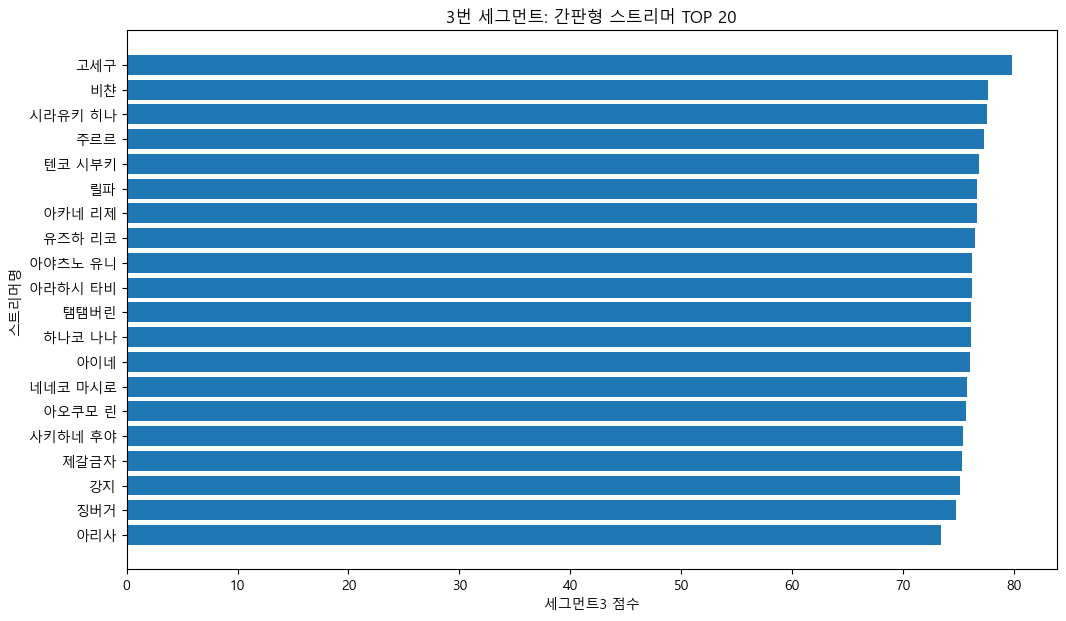

In [156]:
top20 = seg3_result.head(20).copy()

plt.figure(figsize=(12, 7))
plt.barh(top20["스트리머명"], top20["세그먼트3_score"])
plt.gca().invert_yaxis()
plt.xlabel("세그먼트3 점수")
plt.ylabel("스트리머명")
plt.title("3번 세그먼트: 간판형 스트리머 TOP 20")
plt.show()

# 그래프2. 소속구분별 TOP 10

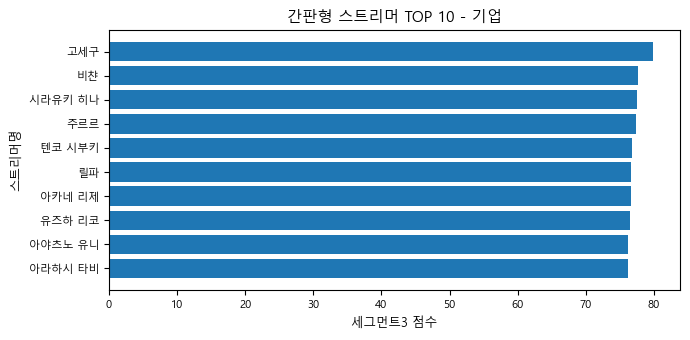

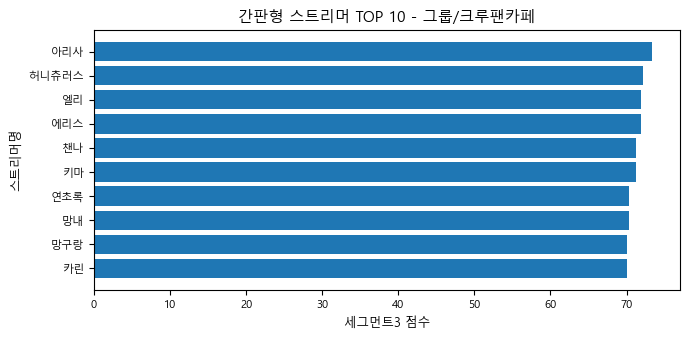

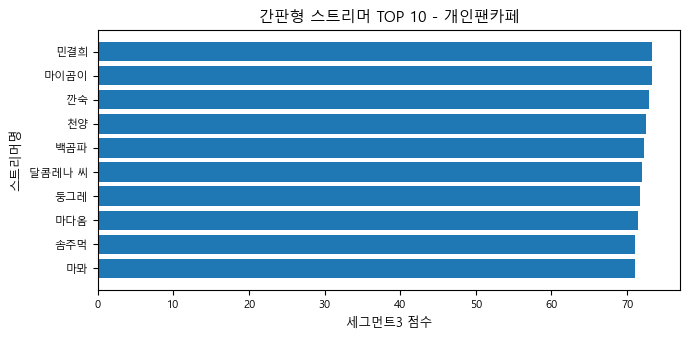

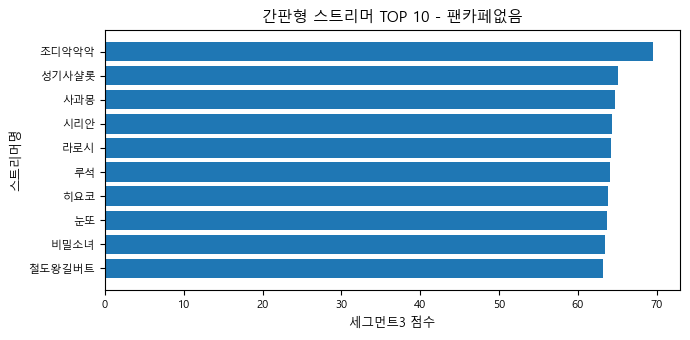

In [148]:
for group_name in seg3_result["소속구분"].unique():
    temp = seg3_result[seg3_result["소속구분"] == group_name].head(10)
    
    if len(temp) == 0:
        continue
    
    plt.figure(figsize=(7, 3.5))
    plt.barh(temp["스트리머명"], temp["세그먼트3_score"])
    plt.gca().invert_yaxis()
    
    plt.xlabel("세그먼트3 점수", fontsize=9)
    plt.ylabel("스트리머명", fontsize=9)
    plt.title(f"간판형 스트리머 TOP 10 - {group_name}", fontsize=11)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    
    plt.tight_layout()
    plt.show()

# 그래프3. 소속구분별 평균 점수 비교

In [147]:
group_mean = (
    seg3_result
    .groupby("소속구분")[
        ["대중성_score", "방송화력_score", "팬덤확장_score", "세그먼트3_score"]
    ]
    .mean()
    .sort_values("세그먼트3_score", ascending=False)
)

group_mean

,대중성_score,방송화력_score,팬덤확장_score,세그먼트3_score
소속구분,,,,
기업,77.913657,91.498958,49.072318,76.137443
그룹/크루팬카페,47.282678,62.238067,35.183983,50.240160
개인팬카페,40.406587,54.251352,30.485491,43.464219
팬카페없음,30.795981,42.115493,20.774356,32.818380


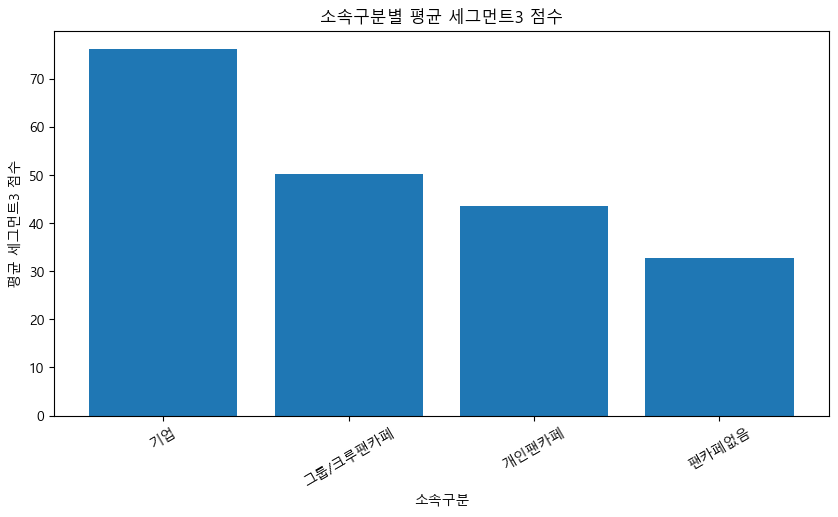

In [149]:
plt.figure(figsize=(10, 5))
plt.bar(group_mean.index, group_mean["세그먼트3_score"])
plt.xlabel("소속구분")
plt.ylabel("평균 세그먼트3 점수")
plt.title("소속구분별 평균 세그먼트3 점수")
plt.xticks(rotation=30)
plt.show()

# 그래프4. 대중성 VS 방송화력 산점도(TOP 300)

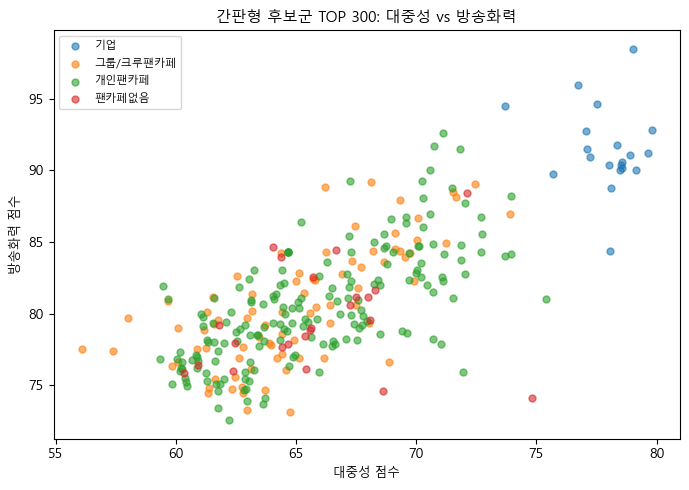

In [151]:
plot_df = seg3_result.head(300).copy()

plt.figure(figsize=(7, 5))

for group_name in plot_df["소속구분"].unique():
    temp = plot_df[plot_df["소속구분"] == group_name]

    plt.scatter(
        temp["대중성_score"],
        temp["방송화력_score"],
        alpha=0.6,
        s=25,
        label=group_name
    )

plt.xlabel("대중성 점수", fontsize=9)
plt.ylabel("방송화력 점수", fontsize=9)
plt.title("간판형 후보군 TOP 300: 대중성 vs 방송화력", fontsize=11)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

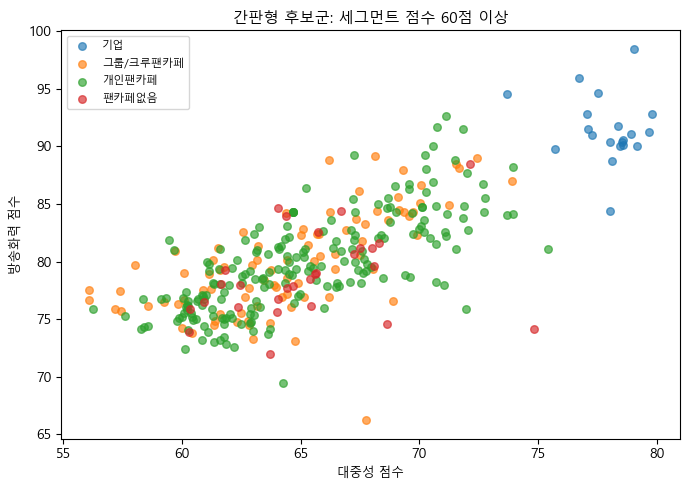

In [153]:
#세그먼트 점수가 60점 이상
plot_df = seg3_result[seg3_result["세그먼트3_score"] >= 60].copy()

plt.figure(figsize=(7, 5))

for group_name in plot_df["소속구분"].unique():
    temp = plot_df[plot_df["소속구분"] == group_name]

    plt.scatter(
        temp["대중성_score"],
        temp["방송화력_score"],
        alpha=0.65,
        s=30,
        label=group_name
    )

plt.xlabel("대중성 점수", fontsize=9)
plt.ylabel("방송화력 점수", fontsize=9)
plt.title("간판형 후보군: 세그먼트 점수 60점 이상", fontsize=11)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

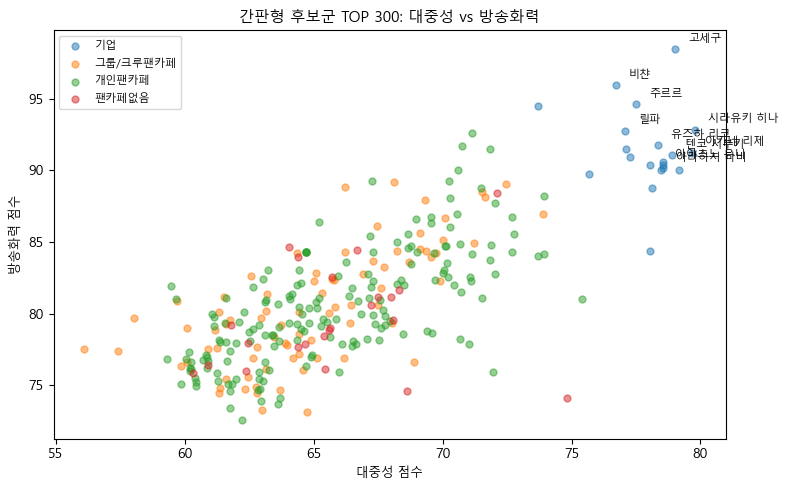

In [159]:
# 상위 10명 이름까지 표시
plot_df = seg3_result.head(300).copy()
label_df = seg3_result.head(10).copy()

plt.figure(figsize=(8, 5))

for group_name in plot_df["소속구분"].unique():
    temp = plot_df[plot_df["소속구분"] == group_name]

    plt.scatter(
        temp["대중성_score"],
        temp["방송화력_score"],
        alpha=0.5,
        s=25,
        label=group_name
    )

for _, row in label_df.iterrows():
    plt.text(
        row["대중성_score"] + 0.5,
        row["방송화력_score"] + 0.5,
        row["스트리머명"],
        fontsize=8
    )

plt.xlabel("대중성 점수", fontsize=9)
plt.ylabel("방송화력 점수", fontsize=9)
plt.title("간판형 후보군 TOP 300: 대중성 vs 방송화력", fontsize=11)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


# 그래프5. 세그먼트 점수 구성 비교 TOP 15

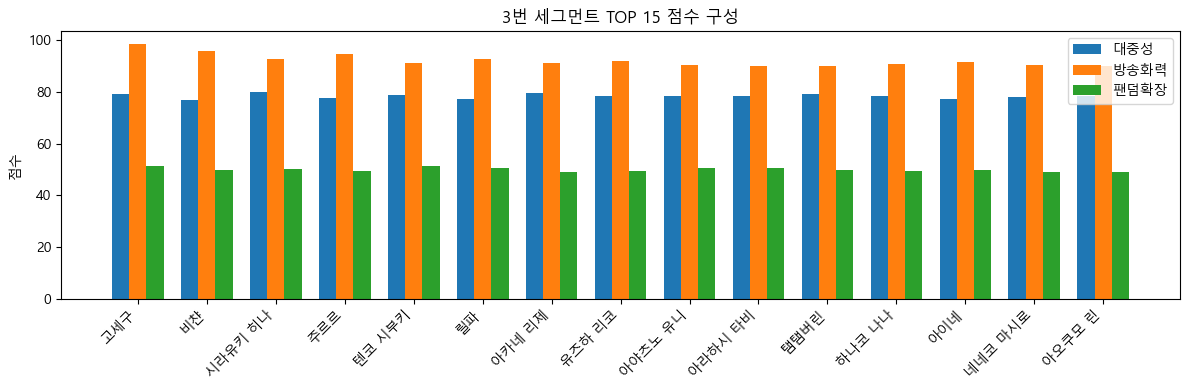

In [155]:
top15 = seg3_result.head(15).copy()

x = np.arange(len(top15))
width = 0.25

plt.figure(figsize=(12, 4))

plt.bar(x - width, top15["대중성_score"], width, label="대중성")
plt.bar(x, top15["방송화력_score"], width, label="방송화력")
plt.bar(x + width, top15["팬덤확장_score"], width, label="팬덤확장")

plt.xticks(x, top15["스트리머명"], rotation=45, ha="right")
plt.ylabel("점수")
plt.title("3번 세그먼트 TOP 15 점수 구성")
plt.legend()
plt.tight_layout()
plt.show()